Assignment 2: Sentiment Analysis using NLP
Pipeline & ML

Name: Tanishka Prasad Jadhav
ID: IN226010302


1. Data Understanding
Load dataset, explore number of samples, class distribution, and sample texts.



In [56]:
import pandas as pd
import numpy as np
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [42]:
#2. Load Dataset
#(Example: IMDb dataset CSV)
df = pd.read_csv(
    "IMDB Dataset.csv",
    engine='python',
    on_bad_lines='skip',
    encoding='utf-8'
)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [43]:
#3. Data Understanding
print("Shape:", df.shape)

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

print("\nSample Reviews:")
print(df['review'].iloc[0])

Shape: (50000, 2)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Reviews:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death star

In [44]:
#4.NLP Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords + Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [45]:
#apply preprocessing
df['clean_text'] = df['review'].apply(preprocess_text)

df[['review', 'clean_text']].head()

,review,clean_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [46]:
# 5. label encoding
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [47]:
#6. Train-Test Split
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
#7. Feature Engineering
# Bag of Words
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [49]:
#TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [50]:
# 8. Model Building
# Logistic Regression
lr = LogisticRegression(max_iter=200)

lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

In [51]:
#Naive Bayes
nb = MultinomialNB()

nb.fit(X_train_bow, y_train)
y_pred_nb = nb.predict(X_test_bow)

In [52]:
#Decision Tree
dt = DecisionTreeClassifier()

dt.fit(X_train_tfidf, y_train)
y_pred_dt = dt.predict(X_test_tfidf)

In [53]:
#9. Model Evaluation
# Logistic Regression
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
#Naive Bayes
print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
#Decision Tree
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Logistic Regression
Accuracy: 0.8846
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Naive Bayes
Accuracy: 0.8457
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      4961
           1       0.85      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Decision Tree
Accuracy: 0.7172
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      4961
           1       0.72      0.71      0.72      5039

    accuracy                           0.72     10000
   macro avg       0.72      0.

In [54]:
#10. Model Comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.8846
1          Naive Bayes    0.8457
2        Decision Tree    0.7172


Observations:
Preprocessing removed noise and improved text clarity
TF-IDF performed better than Bag of Words
Logistic Regression achieved highest accuracy
Naive Bayes is fast but slightly less accurate
Decision Tree tends to overfit

Best Model: Logistic Regression with TF-IDF

Trade-offs:
Naive Bayes-> Fast, less accurate
Decision Tree-> Overfitting risk
Logistic Regression-> Best balance

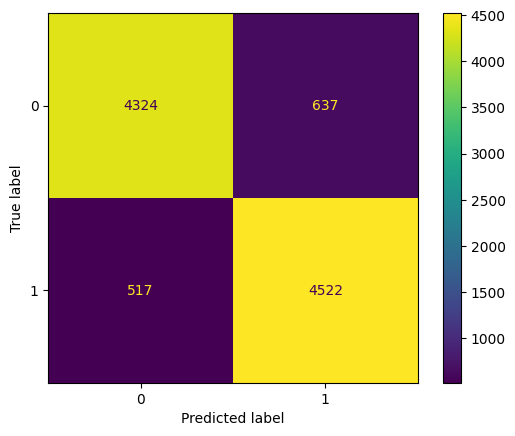

In [55]:
#12. Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

# Final Pipeline
Raw Data -> Preprocessing->Feature Engineering->Model Training-> Evaluation->Comparison